In [ ]:
import numpy as np
import os
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import math
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
import glob


# GETTING DATA

In [4]:
zones = {
    "takeoff": ["W1", "W2", "W3", "W4"],
    "mid":     ["W5", "W6", "W7", "W8"],
    "landing": ["W9", "W10", "W11", "W12"]
}

wind_features = ["Speed", "Tangent", "Cross", "Turbulence"]

In [35]:
def preprocess_flight_normalized(df, step=0.05):
    """
    Preprocess a normalized flight dataframe (already interpolated) to generate states (X), observations (Y), and controls (U).
    
    Args:
        df (pd.DataFrame): Normalized flight dataframe (fixed time step).
        step (float): Time step between rows (used for derivatives).
        
    Returns:
        states (np.ndarray): State matrix [time_steps, state_dim].
        observations (np.ndarray): Observation matrix [time_steps, obs_dim].
        controls (np.ndarray): Control matrix [time_steps, control_dim].
    """

    df.columns = df.columns.str.strip()   #izloči imena stolpcev
    df = df.iloc[1:]
    
    df = df.ffill().bfill()   #back fill za manjkajoče vrednosti
    
    x = df["X [m]"].to_numpy()   #save values
    y = df["Y [m]"].to_numpy()
    z = df["Z [m]"].to_numpy()
    
    dt = step
    #vx = np.gradient(x, dt)   #gradient za hitrost
    vx = df.get("Speed hor. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)
    vy = np.gradient(y, dt)
    #vz = np.gradient(z, dt)
    vz = df.get("Speed ver. [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    speed = df.get("speed resulting [km/h]", pd.Series([0]*len(x))).to_numpy() * (100/36)

    opening = df.get("Opening Angle [°]", pd.Series([0]*len(x))).to_numpy()
    roll_L = df.get("Roll Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    roll_R = df.get("Roll Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_L = df.get("Yaw Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    yaw_R = df.get("Yaw Angle Right [°]", pd.Series([0]*len(x))).to_numpy()
    stall_L = df.get("Stalling Angle Left [°]", pd.Series([0]*len(x))).to_numpy()
    stall_R = df.get("Stalling Angle Right [°]", pd.Series([0]*len(x))).to_numpy()

    states = np.stack([x, y, z, vx, vy, vz, speed, opening, roll_L, roll_R, yaw_L, yaw_R, stall_L, stall_R], axis=1)   #zgradimo state vector X

    height = df.get("Height above ground [m]", pd.Series([0]*len(x))).to_numpy()

    observations = np.stack([x, y, z, height], axis=1)   #zgradimo observation vector Y

    zone_feature_avgs = []
    values = []
    cols = []

    #for feature in wind_features:
    #    for sensor_numb in range(12):
    #        sensor = f"W{sensor_numb + 1}"
    #        cols.append(f"{sensor}_{feature}")
    #        #print(cols)
    #for col in cols:
    #    val = df.get(col, pd.Series([0]*len(x))).to_numpy() 
    #    values.append(val)
    #
    #controls = np.stack(values, axis=1)  # shape: (time_steps, 12)

    for feature in wind_features:
        for zone, sensors in zones.items():
            cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
            avg_feature = df[cols].mean(axis=1).to_numpy()
            zone_feature_avgs.append(avg_feature)
    
    controls = np.stack(zone_feature_avgs, axis=1)  # shape: (time_steps, 12)
    
    return states, observations, controls


In [36]:
for feature in wind_features:
    for zone, sensors in zones.items():
        cols = [f"{sensor}_{feature}" for sensor in sensors if f"{sensor}_{feature}" in df.columns]
        print(cols)
        avg_feature = df[cols].mean(axis=1).to_numpy()
        #zone_feature_avgs.append(avg_feature)

['W1_Speed', 'W2_Speed', 'W3_Speed', 'W4_Speed']
['W5_Speed', 'W6_Speed', 'W7_Speed', 'W8_Speed']
['W9_Speed', 'W10_Speed', 'W11_Speed', 'W12_Speed']
['W1_Tangent', 'W2_Tangent', 'W3_Tangent', 'W4_Tangent']
['W5_Tangent', 'W6_Tangent', 'W7_Tangent', 'W8_Tangent']
['W9_Tangent', 'W10_Tangent', 'W11_Tangent', 'W12_Tangent']
['W1_Cross', 'W2_Cross', 'W3_Cross', 'W4_Cross']
['W5_Cross', 'W6_Cross', 'W7_Cross', 'W8_Cross']
['W9_Cross', 'W10_Cross', 'W11_Cross', 'W12_Cross']
['W1_Turbulence', 'W2_Turbulence', 'W3_Turbulence', 'W4_Turbulence']
['W5_Turbulence', 'W6_Turbulence', 'W7_Turbulence', 'W8_Turbulence']
['W9_Turbulence', 'W10_Turbulence', 'W11_Turbulence', 'W12_Turbulence']


In [ ]:
normalized_folder = r'C:\Users\vsi\Desktop\ijs\smucarski_skoki\project\simulation\2024_03_Planica_12_winds\cleaned\normalized'
combined_output = os.path.join(normalized_folder, "combined_dataset.npz")
file_names = []

X_list, Y_list, U_list = [], [], []

for filename in os.listdir(normalized_folder):
    if filename.endswith('.csv'):
        file_path = os.path.join(normalized_folder, filename)
        df = pd.read_csv(file_path)

        X_state, Y_obs, U_ctrl = preprocess_flight_normalized(df)

        X_list.append(X_state)
        Y_list.append(Y_obs)
        U_list.append(U_ctrl)
        file_names.append(filename)

        #if np.any(np.isnan(X_state)):
        #    print(f"NaN values in {filename}")

        print(f"Processed {filename} -> X:{X_state.shape}, Y:{Y_obs.shape}, U:{U_ctrl.shape}")

# Save combined dataset
np.savez(combined_output, X=np.array(X_list, dtype=object), Y=np.array(Y_list, dtype=object), U=np.array(U_list, dtype=object))
print(f"\nCombined dataset saved to {combined_output}")


Processed 999_999_Jumper_Anon_ANO_1_20240409-102625_C_OfficialResults_cleaned_normalized.csv -> X:(135, 14), Y:(135, 4), U:(135, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102742_C_OfficialResults_cleaned_normalized.csv -> X:(131, 14), Y:(131, 4), U:(131, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102831_C_OfficialResults_cleaned_normalized.csv -> X:(145, 14), Y:(145, 4), U:(145, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102832_C_OfficialResults_cleaned_normalized.csv -> X:(139, 14), Y:(139, 4), U:(139, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102833_C_OfficialResults_cleaned_normalized.csv -> X:(136, 14), Y:(136, 4), U:(136, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102834_C_OfficialResults_cleaned_normalized.csv -> X:(132, 14), Y:(132, 4), U:(132, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102835_C_OfficialResults_cleaned_normalized.csv -> X:(156, 14), Y:(156, 4), U:(156, 12)
Processed 999_999_Jumper_Anon_ANO_1_20240409-102836_C_OfficialResults

functions

In [ ]:

def plot_simulated(X_sim, j, name):
    """
    Plot actual vs simulated trajectory in 3D with projections.
    Args:
        X_seq (ndarray): ground truth state sequence (T, state_dim)
        X_sim (ndarray): simulated state sequence (T, state_dim)
        j (int): index of jump
        name (str): identifier for saving plots """

    #save_dir = f"plots/{name}"
    #os.makedirs(save_dir, exist_ok=True)

    
    sim = X_sim[:, :3]          # samo iz simulacije

    Xs, Ys, Zs = sim[:,0], sim[:,1], sim[:,2]

    length = (Xs[-1]**2 + Ys[-1]**2 + Zs[-1]**2)**(1/2)

    fig = plt.figure(figsize=(8, 5))
    ax = fig.add_subplot(111, projection='3d')

    ax.plot3D(Xs, Ys, Zs, label="Simulated", color="red", linestyle="--")


    # Ground projections
    ax.plot(Xs, 15, Zs, color="red", alpha=0.3, linestyle=':')
    ax.plot(0, Ys, Zs, color="red", alpha=0.3, linestyle=':')


    ax.set_title(f"Simulated Trajectory\n Jump length: {length:.3f})")
    ax.set_xlabel("X [m]")
    ax.set_ylabel("Y [m]")
    ax.set_zlabel("Z [m]")
    ax.legend()
    ax.set_box_aspect([1,1,1])
    ax.set_ylim(-15, 15)

    plt.legend()
    plt.show()


In [ ]:
#from sklearn.model_selection import KFold

def fit_ssm_test(X_list, U_list, Y_list,j=-29, wind_value=2, n_splits=5, alpha=1e-3):
    """
    Fit an SSM model.

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        the plot of the one element separated and adjusted
    """
    #kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    train_errors, test_errors = [], []
    models = []

    train_idx = [i for i in range(len(X_list) - 1)]

    # --- build training data ---
    X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
    X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
    U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
    Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

    # Regression [X_next] ~ [X_t | U_t]
    Phi = np.hstack([X_t, U_t])
    ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
            #
    ridge.fit(Phi, X_next)
    Theta = ridge.coef_.T

    state_dim = X_t.shape[1]
    control_dim = U_t.shape[1]
    A = Theta[:state_dim, :].T
    B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
    Phi_y = np.hstack([X_t, U_t])
    ridge_y = Ridge(alpha=alpha, fit_intercept=False)
    ridge_y.fit(Phi_y, Y_t)
    Theta_y = ridge_y.coef_.T

    obs_dim = Y_t.shape[1]
    C = Theta_y[:state_dim, :].T
    D = Theta_y[state_dim:, :].T

    models.append(A, B, C, D)

        # --- compute training error ---
    train_sim = X_t @ A.T + U_t @ B.T
    train_err = np.mean(np.linalg.norm(train_sim[:, :3] - X_next[:, :3], axis=1))
    #train_err = penalized_bidirectional_distance(train_sim[::10], X_next[::10])
    train_errors.append(train_err)

        # --- compute test error ---
    test_errs = []

    
    x0 = X_list[j][0]       #initial state...maybe don't adjust
    U_seq = np.copy(U_list[j]) * 0      #winds...you can adjust
    X_seq = X_list[j]

    file_length = len(U_seq)
    
    print(U_seq[0])


    X_sim = [x0]

    for t in range(file_length-1):
        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
    X_sim = np.array(X_sim)

    plot_simulated(X_sim, j, "2-SSM")


[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0. -0. -0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


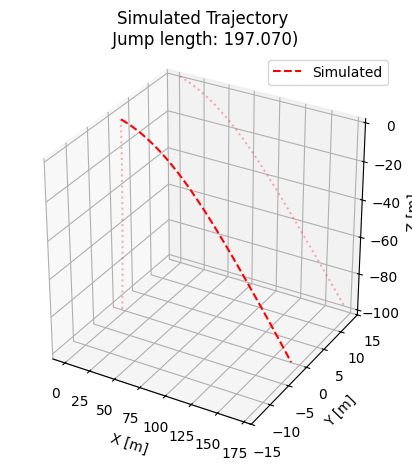

In [9]:
fit_ssm_test(X_list, U_list, Y_list, -29, -3, n_splits=len(X_list), alpha=10)


In [10]:
U_z = np.copy(U_list[-29]) * 0 + 1
U_z

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(127, 48))

# FUNCTIONS FOR SLIDERS

In [ ]:

def build_models(X_list, U_list, Y_list,j=-29, wind_value=2, n_splits=5, alpha=1e-3):
    """
    Build the matrices and arrays for simulation

    Args:
        X_list, U_list, Y_list: lists of arrays (one per jump)
        n_splits (int): number of folds (or = len(X_list) for LOOCV)
        alpha (float): ridge regularization parameter

    Returns:
        the calculated matrices
    """
    #train_errors, test_errors = [], []
    models = []

    train_idx = [i for i in range(len(X_list) - 1)]

    # build training data
    X_t = np.vstack([seq[:-1] for i, seq in enumerate(X_list) if i in train_idx])
    X_next = np.vstack([seq[1:] for i, seq in enumerate(X_list) if i in train_idx])
    U_t = np.vstack([u[:-1] for i, u in enumerate(U_list) if i in train_idx])
    Y_t = np.vstack([y[:-1] for i, y in enumerate(Y_list) if i in train_idx])

    # Regression [X_next] ~ [X_t | U_t]
    Phi = np.hstack([X_t, U_t])
    ridge = Ridge(alpha=alpha, fit_intercept=False)     #ridge is just MNK z regularizacijo
    ridge.fit(Phi, X_next)
    Theta = ridge.coef_.T

    state_dim = X_t.shape[1]
    control_dim = U_t.shape[1]
    A = Theta[:state_dim, :].T
    B = Theta[state_dim:, :].T

        # Regression [Y_t] ~ [X_t | U_t]
    Phi_y = np.hstack([X_t, U_t])
    ridge_y = Ridge(alpha=alpha, fit_intercept=False)
    ridge_y.fit(Phi_y, Y_t)
    Theta_y = ridge_y.coef_.T

    obs_dim = Y_t.shape[1]
    C = Theta_y[:state_dim, :].T
    D = Theta_y[state_dim:, :].T

    models = [A, B, C, D]

    return models


In [63]:
def app_sim(X_important, models, sliders=np.zeros(19)):

    A, B, C, D = models[0], models[1], models[2], models[3]
    winds = sliders[0:12]
    x0 = X_important[0]       #initial state...maybe don't adjust
    X_sim = [x0]
    X_coord = [x0[:3]]
    U_seq = []
    file_length = np.shape(X_important)[0]

    for i in range(file_length):
        U_seq.append(winds)

    for t in range(file_length-1):
        x_next = A @ X_sim[-1] + B @ U_seq[t]
        X_sim.append(x_next)
        X_coord.append(x_next[:3])
    X_sim = np.array(X_sim)


    return X_coord

In [ ]:
models = build_models(X_list, U_list, Y_list)
X_important = X_list[-29]
app_sim(X_important, models)

[array([ 0.38127451,  0.00245098, -0.05901961]),
 array([ 1.36051023,  0.00517244, -0.24595436]),
 array([ 2.36337057,  0.00767112, -0.44109922]),
 array([ 3.38912678,  0.00990591, -0.64508865]),
 array([ 4.43703715,  0.01185032, -0.8585232 ]),
 array([ 5.50634956,  0.01348882, -1.08196946]),
 array([ 6.59630378,  0.01481399, -1.31596011]),
 array([ 7.70613382,  0.01582433, -1.56099398]),
 array([ 8.83507009,  0.01652269, -1.81753622]),
 array([ 9.98234144,  0.01691494, -2.08601853]),
 array([11.14717721,  0.01700907, -2.36683946]),
 array([12.32880903,  0.01681445, -2.66036475]),
 array([13.52647268,  0.01634129, -2.96692778]),
 array([14.7394097 ,  0.01560026, -3.28683006]),
 array([ 1.59668690e+01,  1.46021580e-02, -3.62034174e+00]),
 array([ 1.72081085e+01,  1.33576872e-02, -3.96770228e+00]),
 array([ 1.84623961e+01,  1.18773179e-02, -4.32912106e+00]),
 array([ 1.97290114e+01,  1.01711561e-02, -4.70477812e+00]),
 array([ 2.10072469e+01,  8.24886686e-03, -5.09482488e+00]),
 array([ 

In [65]:
X_important

array([[ 3.81274510e-01,  2.45098039e-03, -5.90196078e-02, ...,
        -2.70833333e-01, -1.11276961e+01, -1.12779412e+01],
       [ 6.92549020e-01,  4.90196078e-03, -1.08039216e-01, ...,
        -5.41666667e-01, -1.07553922e+01, -1.10558824e+01],
       [ 1.00382353e+00,  7.35294118e-03, -1.57058824e-01, ...,
        -8.12500000e-01, -1.03830882e+01, -1.08338235e+01],
       ...,
       [ 1.62594074e+02,  4.73333333e+00, -9.62948148e+01, ...,
        -3.34788889e+00, -1.29744815e+01, -1.20309259e+01],
       [ 1.63966897e+02,  4.83793103e+00, -9.74451724e+01, ...,
        -1.58513793e+00, -2.00787931e+01, -1.99922414e+01],
       [ 1.65308519e+02,  4.88481481e+00, -9.85422222e+01, ...,
         8.68592593e-01, -2.76856667e+01, -2.87682963e+01]],
      shape=(127, 14))

### saving results

In [ ]:
np.savetxt("xImportant.csv", X_important, delimiter=",")

In [74]:
A, B, C, D = models[0], models[1], models[2], models[3]

np.savetxt("matrixA.csv", A, delimiter=",")
np.savetxt("matrixB.csv", B, delimiter=",")
np.savetxt("matrixC.csv", C, delimiter=",")
np.savetxt("matrixD.csv", D, delimiter=",")


# AVERAGE FILE

In [ ]:

file_paths = glob.glob("2024_03_Planica_12_winds/cleaned/*.csv")  #fake regularni za iskanje poti

flights = []
headers = None

# Read files
for idx, fp in enumerate(file_paths):
    df = pd.read_csv(fp)
    if idx == 0:
        headers = df.columns  # store header from first file
    arr = df.values
    flights.append(arr)

common_points = 1000
grid = np.linspace(0, 1, common_points)

resampled = []
for f in flights:
    n, d = f.shape
    x_old = np.linspace(0, 1, n)
    f_interp = np.zeros((common_points, d))
    for j in range(d):
        f_interp[:, j] = np.interp(grid, x_old, f[:, j])
    resampled.append(f_interp)

resampled = np.array(resampled)
avg_flight = np.mean(resampled, axis=0)

avg_length = int(np.mean([f.shape[0] for f in flights]))
final_grid = np.linspace(0, 1, avg_length)
avg_resampled = np.zeros((avg_length, avg_flight.shape[1]))
for j in range(avg_flight.shape[1]):
    avg_resampled[:, j] = np.interp(final_grid, grid, avg_flight[:, j])

# Create DataFrame with header from first file
avg_df = pd.DataFrame(avg_resampled, columns=headers)

# Save
avg_df.to_csv("average_flight.csv", index=False)


## try 2 (sum matrices...vzame največji skok in zelo zmanjša vrednosti)

In [4]:
import pandas as pd
import numpy as np
import glob

# 1. Collect file paths
file_paths = glob.glob("2024_03_Planica_12_winds/cleaned/*.csv")

# 2. Read one file just to get header
sample = pd.read_csv(file_paths[0])
header = list(sample.columns)
n_cols = len(header)

# 3. Find maximum number of rows across all files
max_rows = max(pd.read_csv(fp).shape[0] for fp in file_paths)

# 4. Initialize sum matrix and NaN mask
sum_matrix = np.zeros((max_rows, n_cols))
nan_mask = np.zeros((max_rows, n_cols), dtype=bool)

# 5. Process each file
for fp in file_paths:
    df = pd.read_csv(fp)
    arr = df.values.astype(object)
    rows = arr.shape[0]

    for i in range(max_rows):
        for j in range(n_cols):
            if i < rows:
                val = arr[i, j]
                if pd.isna(val):
                    if i < 100:
                        nan_mask[i, j] = True   # force NaN in final
                    else:
                        sum_matrix[i, j] += 0   # treat as 0
                else:
                    sum_matrix[i, j] += float(val)
            else:
                # file shorter: treat as NaN or 0 depending on row index
                if i < 100:
                    nan_mask[i, j] = True
                else:
                    sum_matrix[i, j] += 0

# 6. Divide by number of files
avg_matrix = sum_matrix / len(file_paths)

# 7. Apply NaN mask
avg_matrix[nan_mask] = np.nan

# 8. Save result
avg_df = pd.DataFrame(avg_matrix, columns=header)
avg_df.to_csv("average_flight.csv", index=False)


### try 2.2

In [6]:
import pandas as pd
import numpy as np
import glob

# 1. Collect file paths
file_paths = glob.glob("2024_03_Planica_12_winds/cleaned/*.csv")

# 2. Read one file just to get header
sample = pd.read_csv(file_paths[0])
header = list(sample.columns)
n_cols = len(header)

# 3. Find maximum number of rows across all files
max_rows = max(pd.read_csv(fp).shape[0] for fp in file_paths)

# 4. Initialize sum and count matrices, plus NaN mask
sum_matrix = np.zeros((max_rows, n_cols))
count_matrix = np.zeros((max_rows, n_cols))
nan_mask = np.zeros((max_rows, n_cols), dtype=bool)

# 5. Process each file
for fp in file_paths:
    df = pd.read_csv(fp)
    arr = df.values.astype(object)
    rows = arr.shape[0]

    for i in range(rows):  # only loop through existing rows
        for j in range(n_cols):
            val = arr[i, j]

            if pd.isna(val):
                if i < 100:
                    nan_mask[i, j] = True   # force NaN in final
                # else: skip (no update to sum or count)
            else:
                sum_matrix[i, j] += float(val)
                count_matrix[i, j] += 1

# 6. Compute averages safely
with np.errstate(invalid="ignore", divide="ignore"):
    avg_matrix = sum_matrix / count_matrix

# 7. Apply NaN mask (force NaNs for rows < 100 if needed)
avg_matrix[nan_mask] = np.nan

# 8. Save result
avg_df = pd.DataFrame(avg_matrix, columns=header)
avg_df.to_csv("average_flight.csv", index=False)


code works, the output just doesn't make too much sense